# Preprocessing dan AHC Kota Palembang (Step-by-Step)
Alur utama:
1. Setup environment dan import library
2. Siapkan data contoh dari file asli
3. Validasi input
4. Tahapan preprocessing (load, cleaning, selection, reduction, transformation)
5. Tabel data awal per tahun ajaran
6. Clustering: mean, variance, standard deviation (per tahun)
7. Clustering: z-score (per tahun)
8. Clustering AHC: single, complete, average (per tahun)

## 1) Setup Environment dan Import Library
Jalankan sel ini terlebih dahulu. Jika ada package yang belum tersedia, aktifkan baris instalasi.

In [2]:
# Jika diperlukan di Colab, buka komentar berikut:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn scipy

import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML, display as ipy_display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

# Paksa tampilan tabel rata kiri
a = """
<style>
table.dataframe thead th, table.dataframe tbody th, table.dataframe td {
  text-align: left !important;
  white-space: normal !important;
}
</style>
"""
ipy_display(HTML(a))


def _to_id_numeric_string(x, decimals=None, trim_decimal=False):
    if pd.isna(x):
        return ''

    val = float(x)
    if decimals is None:
        # Tanpa desimal jika bilangan bulat, selain itu pakai 3 desimal.
        if val.is_integer():
            s = f'{int(val):,}'
        else:
            s = f'{val:,.3f}'
            if trim_decimal:
                s = s.rstrip('0').rstrip('.')
    else:
        s = f'{val:,.{decimals}f}'
        if trim_decimal:
            s = s.rstrip('0').rstrip('.')

    # Ubah ke format Indonesia: ribuan '.' dan desimal ','.
    s = s.replace(',', 'X').replace('.', ',').replace('X', '.')
    return s


def _fmt_max3(x):
    # Maksimal 3 desimal, dengan format Indonesia.
    return _to_id_numeric_string(x, decimals=3, trim_decimal=True)


def _fmt_ratio_2dec_comma(x):
    if pd.isna(x):
        return ''
    # Format rasio: 2 angka desimal, separator desimal koma, tanpa pemisah ribuan.
    return f'{float(x):.2f}'.replace('.', ',')


def _fmt_general_numeric(x):
    # Angka umum: ribuan pakai titik; jika ada pecahan tampilkan maks 3 desimal.
    return _to_id_numeric_string(x, decimals=None, trim_decimal=True)


def _fmt_year_plain(x):
    if pd.isna(x):
        return ''
    x = float(x)
    if x.is_integer():
        return str(int(x))
    return str(x)


def show_df(df):
    """Tampilkan DataFrame tanpa index, hapus Nomor, No di kiri, dan rapikan format angka."""
    if isinstance(df, pd.DataFrame):
        temp = df.copy()

        # Bersihkan dulu kolom penomoran lama jika ada
        for col in ['Nomor', 'No']:
            if col in temp.columns:
                temp = temp.drop(columns=[col])

        # Rapikan kolom numerik
        for col in temp.columns:
            col_norm = str(col).strip().lower()

            # NPSN harus tetap angka polos tanpa titik/pemisah ribuan.
            if 'npsn' in col_norm:
                temp[col] = temp[col].astype(str).str.replace(r'[^0-9]', '', regex=True)
                continue

            numeric_col = pd.to_numeric(temp[col], errors='coerce')
            mask = numeric_col.notna()

            if mask.any():
                # Semua kolom tahun tampil polos tanpa titik ribuan.
                if ('tahun' in col_norm) and ('ajaran' not in col_norm):
                    temp.loc[mask, col] = numeric_col.loc[mask].map(_fmt_year_plain)
                # Kolom rasio: selalu 2 desimal dengan koma
                elif 'rasio' in col_norm:
                    temp.loc[mask, col] = numeric_col.loc[mask].map(_fmt_ratio_2dec_comma)
                # Jumlah penduduk: format Indonesia, maks 3 desimal
                elif ('jumlah penduduk' in col_norm) or ('jumlah_penduduk' in col_norm):
                    temp.loc[mask, col] = numeric_col.loc[mask].map(_fmt_max3)
                else:
                    # Variabel numerik lain: format Indonesia (ribuan pakai titik)
                    temp.loc[mask, col] = numeric_col.loc[mask].map(_fmt_general_numeric)

        # Tambahkan nomor urut baru di paling kiri
        temp.insert(0, 'No', range(1, len(temp) + 1))

        styled = (
            temp.style
            .hide(axis='index')
            .set_properties(**{'text-align': 'left', 'white-space': 'normal'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left !important')]},
                {'selector': 'td', 'props': [('text-align', 'left !important'), ('white-space', 'normal !important')]},
            ])
        )
        ipy_display(styled)
    else:
        ipy_display(df)


print('pandas      :', pd.__version__)
print('numpy       :', np.__version__)
print('seaborn     :', sns.__version__)

pandas      : 2.1.0
numpy       : 1.24.3
seaborn     : 0.13.2


## 2) Siapkan Data Contoh Bertahap
Sel ini mengatur path data, load data sumber, lalu tampilkan 5 baris awal agar struktur data terverifikasi sebelum lanjut.

In [3]:
# Path lokal Windows (sesuai folder Anda)
POPULATION_FILE = r'D:\WEBSITE ME\simpemgu\dataset csv\data_all_total\jumlah-penduduk.csv'
SCHOOL_DIR = r'D:\WEBSITE ME\simpemgu\dataset csv\nama sd_per_kecamatan'
OUTPUT_DIR = r'D:\WEBSITE ME\simpemgu\output\colab_hasil'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Rentang tahun ajaran analisis
TAHUN_AWAL = 2019
TAHUN_AKHIR = 2024  # mewakili 2024-2025

# Mode cepat
FAST_MODE = False
QUICK_TAHUN_AJARAN = '2024-2025'  # dipakai saat FAST_MODE=True
MAX_FILES_FAST = 20               # batasi jumlah file agar loading cepat
PLOT_DENDROGRAM_FAST = False      # matikan plot dendrogram saat mode cepat

print('POPULATION_FILE:', POPULATION_FILE)
print('SCHOOL_DIR     :', SCHOOL_DIR)
print('OUTPUT_DIR     :', OUTPUT_DIR)
print('Rentang tahun  :', f'{TAHUN_AWAL}-{TAHUN_AKHIR + 1}')
print('FAST_MODE      :', FAST_MODE)

# Preview data penduduk (5 baris)
pop_preview = pd.read_csv(POPULATION_FILE)
print('\nPreview data penduduk:')
show_df(pop_preview.head())

# Preview 1 file sekolah (5 baris)
school_files = sorted(glob.glob(os.path.join(SCHOOL_DIR, '*.csv')))
print('\nJumlah file sekolah (semua):', len(school_files))
assert len(school_files) > 0, 'Folder nama sd_per_kecamatan kosong atau path salah.'

one_file = school_files[0]
print('Contoh file sekolah:', os.path.basename(one_file))
school_preview = pd.read_csv(one_file, sep=';', skiprows=1, dtype=str, engine='python')
school_preview = school_preview.loc[:, ~school_preview.columns.str.contains('^Unnamed')]

# Parse metadata langsung di cell ini agar tidak tergantung urutan eksekusi cell lain
meta_match = re.search(r'^(.*?)\s+(\d{4})-(\d{4})\s+ganjil$', os.path.basename(one_file).replace('.csv', ''), flags=re.IGNORECASE)
if meta_match:
    school_preview.insert(0, 'kecamatan', meta_match.group(1).strip())
    school_preview.insert(1, 'tahun_ajaran', f"{meta_match.group(2)}-{meta_match.group(3)}")

show_df(school_preview.head())

POPULATION_FILE: D:\WEBSITE ME\simpemgu\dataset csv\data_all_total\jumlah-penduduk.csv
SCHOOL_DIR     : D:\WEBSITE ME\simpemgu\dataset csv\nama sd_per_kecamatan
OUTPUT_DIR     : D:\WEBSITE ME\simpemgu\output\colab_hasil
Rentang tahun  : 2019-2025
FAST_MODE      : False

Preview data penduduk:


No,Kecamatan,Jumlah Penduduk 2018 (jiwa),Jumlah Penduduk 2019 (jiwa),Jumlah Penduduk 2020 (jiwa),Jumlah Penduduk 2021 (jiwa),Jumlah Penduduk 2022 (jiwa),Jumlah Penduduk 2023 (jiwa),Jumlah Penduduk 2024 (jiwa)
1,Alang-Alang Lebar,"97,455","98,537","105,201","106,641","110,085","113,578","116,594"
2,Bukit Kecil,"49,657","50,301","38,585","38,566","38,704","38,226","38,195"
3,Gandus,"64,994","65,782","73,953","75,394","78,722","81,146","83,882"
4,Ilir Barat I,"139,933","141,544","140,945","141,855","144,355","151,894","154,738"
5,Ilir Barat II,"72,387","73,269","67,614","67,647","68,026","69,665","69,871"



Jumlah file sekolah (semua): 108
Contoh file sekolah: alang-alang lebar 2019-2020 ganjil.csv


No,kecamatan,tahun_ajaran,Nama Sekolah,NPSN,BP,Status,Last Sync,Jml Sync,PD,Rombel,Guru,Pegawai,R. Kelas,R. Lab,R. Perpus
1,alang-alang lebar,2019-2020,SD NEGERI 237 PALEMBANG,10604271,SD,Negeri,07 Mar 2026 08:11:30,8,102,6,7,4,6,0,1
2,alang-alang lebar,2019-2020,SD NEGERI 238 PALEMBANG,10609400,SD,Negeri,04 Mar 2026 10:06:19,62,588,19,24,6,6,0,1
3,alang-alang lebar,2019-2020,SD NEGERI 239 PALEMBANG,10604270,SD,Negeri,07 Mar 2026 10:58:50,9,226,10,17,3,7,0,0
4,alang-alang lebar,2019-2020,SD NEGERI 240 PALEMBANG,10604265,SD,Negeri,03 Mar 2026 10:24:04,31,538,19,25,4,7,0,1
5,alang-alang lebar,2019-2020,SD NEGERI 241 PALEMBANG,10604276,SD,Negeri,11 Mar 2026 12:13:25,27,908,26,33,6,10,1,1


## 3) Sel 1: Validasi Input
Tahap ini memastikan kolom wajib tersedia, tipe data bisa dikonversi, dan nilai penting tidak kosong. Jika gagal, hentikan di sini dan perbaiki data terlebih dahulu.

In [4]:
def normalize_kecamatan_name(text: str) -> str:
    text = str(text).strip().lower()
    text = text.replace('kec.', '').replace('kecamatan', '')
    text = re.sub(r'\s+', ' ', text)
    return text


def parse_population_value(value):
    if pd.isna(value):
        return np.nan
    txt = str(value).strip().replace(',', '.')
    txt = re.sub(r'[^0-9.]', '', txt)
    if txt == '':
        return np.nan
    num = float(txt)
    if num < 1000:
        num = num * 1000
    return int(round(num))


def extract_meta_from_filename(path: str):
    name = os.path.basename(path).replace('.csv', '')
    m = re.search(r'^(.*?)\s+(\d{4})-(\d{4})\s+ganjil$', name, flags=re.IGNORECASE)
    if not m:
        return None
    return {
        'kecamatan_file': m.group(1).strip(),
        'kecamatan_norm': normalize_kecamatan_name(m.group(1).strip()),
        'tahun_ajaran': f"{m.group(2)}-{m.group(3)}",
        'tahun': int(m.group(2)),
        'source_file': os.path.basename(path)
    }


# Validasi file penduduk
assert os.path.exists(POPULATION_FILE), 'File jumlah-penduduk.csv tidak ditemukan.'
pop_df = pd.read_csv(POPULATION_FILE)
assert 'Kecamatan' in pop_df.columns, "Kolom 'Kecamatan' tidak ada di file penduduk."

year_cols = [c for c in pop_df.columns if 'Jumlah Penduduk' in c]
assert len(year_cols) > 0, 'Kolom jumlah penduduk per tahun tidak ditemukan.'

# Validasi file sekolah
assert os.path.isdir(SCHOOL_DIR), 'Folder nama sd_per_kecamatan tidak ditemukan.'
assert len(school_files) > 0, 'Tidak ada file sekolah .csv yang ditemukan.'

sample_school = pd.read_csv(school_files[0], sep=';', skiprows=1, dtype=str, engine='python')
sample_school = sample_school.loc[:, ~sample_school.columns.str.contains('^Unnamed')]
req_school_cols = ['Nama Sekolah', 'PD', 'Rombel', 'Guru']
missing = [c for c in req_school_cols if c not in sample_school.columns]
assert not missing, f'Kolom wajib file sekolah tidak lengkap: {missing}'

print('Validasi input selesai: format dasar data sudah sesuai.')

Validasi input selesai: format dasar data sudah sesuai.


## 4) Tahapan Preprocessing
Di bagian ini, setiap langkah dibuat terpisah agar alurnya mudah dibaca dan tidak tercampur.

In [11]:
# -----------------------------
# Fungsi bantu (dipakai di semua tahap)
# -----------------------------
def load_population_long(pop_file: str) -> pd.DataFrame:
    df = pd.read_csv(pop_file)
    year_cols = [c for c in df.columns if 'Jumlah Penduduk' in c]
    id_cols = [c for c in df.columns if c not in year_cols]

    long_df = df.melt(id_vars=id_cols, value_vars=year_cols,
                      var_name='tahun_label', value_name='jumlah_penduduk_raw')
    long_df['tahun'] = long_df['tahun_label'].str.extract(r'(\d{4})').astype(int)
    long_df['jumlah_penduduk'] = long_df['jumlah_penduduk_raw'].apply(parse_population_value)
    long_df['kecamatan_norm'] = long_df['Kecamatan'].apply(normalize_kecamatan_name)

    out = long_df[['Kecamatan', 'kecamatan_norm', 'tahun', 'jumlah_penduduk']].copy()
    out = out.rename(columns={'Kecamatan': 'kecamatan'})
    out = out.dropna(subset=['jumlah_penduduk'])
    return out


def read_school_csv(path: str) -> pd.DataFrame:
    meta = extract_meta_from_filename(path)
    if meta is None:
        return pd.DataFrame()

    df = pd.read_csv(path, sep=';', skiprows=1, dtype=str, encoding='utf-8', engine='python')
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.dropna(axis=1, how='all')
    df.columns = [str(c).strip() for c in df.columns]

    required = ['Nama Sekolah', 'PD', 'Rombel', 'Guru']
    if not all(c in df.columns for c in required):
        return pd.DataFrame()

    keep_cols = ['Nama Sekolah', 'NPSN', 'BP', 'Status', 'PD', 'Rombel', 'Guru']
    keep_cols = [c for c in keep_cols if c in df.columns]
    out = df[keep_cols].copy()

    # Kolom hitungan (PD/Rombel/Guru) dipaksa menjadi integer: hapus semua non-digit.
    # Ini mencegah kasus 1,067 terbaca sebagai 1.067.
    for col in ['PD', 'Rombel', 'Guru']:
        digits = out[col].astype(str).str.replace(r'[^0-9]', '', regex=True)
        out[col] = pd.to_numeric(digits, errors='coerce')

    out['kecamatan'] = meta['kecamatan_norm']
    out['tahun_ajaran'] = meta['tahun_ajaran']

    out = out.dropna(subset=['Nama Sekolah'])
    out = out[out['Nama Sekolah'].astype(str).str.strip() != '']
    return out

FAST_MODE nonaktif: file dipakai=108
Tahap 1 - Load Data selesai
pop_long shape  : (126, 4)
school_raw shape: (8928, 9)


No,kecamatan,kecamatan_norm,tahun,jumlah_penduduk
1,Alang-Alang Lebar,alang-alang lebar,2018,97.455
2,Bukit Kecil,bukit kecil,2018,49.657
3,Gandus,gandus,2018,64.994
4,Ilir Barat I,ilir barat i,2018,139.933
5,Ilir Barat II,ilir barat ii,2018,72.387


No,Nama Sekolah,NPSN,BP,Status,PD,Rombel,Guru,kecamatan,tahun_ajaran
1,SD NEGERI 237 PALEMBANG,10604271,SD,Negeri,102,6,7,alang-alang lebar,2019-2020
2,SD NEGERI 238 PALEMBANG,10609400,SD,Negeri,588,19,24,alang-alang lebar,2019-2020
3,SD NEGERI 239 PALEMBANG,10604270,SD,Negeri,226,10,17,alang-alang lebar,2019-2020
4,SD NEGERI 240 PALEMBANG,10604265,SD,Negeri,538,19,25,alang-alang lebar,2019-2020
5,SD NEGERI 241 PALEMBANG,10604276,SD,Negeri,908,26,33,alang-alang lebar,2019-2020


In [23]:
# Tahap 1: Load Data
pop_long = load_population_long(POPULATION_FILE)

# Mode cepat: pakai 1 tahun ajaran + batasi jumlah file
if FAST_MODE:
    school_files_used = [f for f in school_files if QUICK_TAHUN_AJARAN in os.path.basename(f)]
    school_files_used = school_files_used[:MAX_FILES_FAST]
    print(f"FAST_MODE aktif: tahun={QUICK_TAHUN_AJARAN}, file dipakai={len(school_files_used)}")
else:
    school_files_used = school_files
    print(f"FAST_MODE nonaktif: file dipakai={len(school_files_used)}")

school_frames = []
for fp in school_files_used:
    one = read_school_csv(fp)
    if not one.empty:
        school_frames.append(one)

if len(school_frames) == 0:
    raise ValueError('Tidak ada data sekolah yang berhasil dibaca. Cek QUICK_TAHUN_AJARAN atau format file.')

school_raw = pd.concat(school_frames, ignore_index=True)

print('Tahap 1 - Load Data selesai')
print('pop_long shape  :', pop_long.shape)
print('school_raw shape:', school_raw.shape)
show_df(pop_long.head())
show_df(school_raw.head())

FAST_MODE nonaktif: file dipakai=108
Tahap 1 - Load Data selesai
pop_long shape  : (126, 4)
school_raw shape: (8928, 9)


No,kecamatan,kecamatan_norm,tahun,jumlah_penduduk
1,Alang-Alang Lebar,alang-alang lebar,2018,97.455
2,Bukit Kecil,bukit kecil,2018,49.657
3,Gandus,gandus,2018,64.994
4,Ilir Barat I,ilir barat i,2018,139.933
5,Ilir Barat II,ilir barat ii,2018,72.387


No,Nama Sekolah,NPSN,BP,Status,PD,Rombel,Guru,kecamatan,tahun_ajaran
1,SD NEGERI 237 PALEMBANG,10604271,SD,Negeri,102,6,7,alang-alang lebar,2019-2020
2,SD NEGERI 238 PALEMBANG,10609400,SD,Negeri,588,19,24,alang-alang lebar,2019-2020
3,SD NEGERI 239 PALEMBANG,10604270,SD,Negeri,226,10,17,alang-alang lebar,2019-2020
4,SD NEGERI 240 PALEMBANG,10604265,SD,Negeri,538,19,25,alang-alang lebar,2019-2020
5,SD NEGERI 241 PALEMBANG,10604276,SD,Negeri,908,26,33,alang-alang lebar,2019-2020


### Tahap 2: Data Cleaning
Menghapus duplikasi, menangani nilai kosong, dan membuang nilai tidak wajar agar data siap dipakai.

In [12]:
school_clean = school_raw.drop_duplicates(
    subset=['tahun_ajaran', 'kecamatan', 'Nama Sekolah', 'NPSN'],
    keep='last'
).copy()

school_clean = school_clean.dropna(subset=['PD', 'Guru', 'Rombel'])
# Guru boleh 0 agar sekolah tetap terhitung pada jumlah_sekolah.
school_clean = school_clean[(school_clean['PD'] >= 0) & (school_clean['Guru'] >= 0) & (school_clean['Rombel'] >= 0)]

print('Tahap 2 - Data Cleaning selesai')
print('school_clean shape:', school_clean.shape)
show_df(school_clean.head())

Tahap 2 - Data Cleaning selesai
school_clean shape: (8928, 9)


No,Nama Sekolah,NPSN,BP,Status,PD,Rombel,Guru,kecamatan,tahun_ajaran
1,SD NEGERI 237 PALEMBANG,10604271,SD,Negeri,102,6,7,alang-alang lebar,2019-2020
2,SD NEGERI 238 PALEMBANG,10609400,SD,Negeri,588,19,24,alang-alang lebar,2019-2020
3,SD NEGERI 239 PALEMBANG,10604270,SD,Negeri,226,10,17,alang-alang lebar,2019-2020
4,SD NEGERI 240 PALEMBANG,10604265,SD,Negeri,538,19,25,alang-alang lebar,2019-2020
5,SD NEGERI 241 PALEMBANG,10604276,SD,Negeri,908,26,33,alang-alang lebar,2019-2020


### Tahap 3: Data Selection (Khusus SD)
Memilih hanya data jenjang SD, lalu mengambil variabel utama: `Guru`, `Status`, `PD`, dan `Rombel` (dengan kolom identitas minimum untuk analisis).

In [13]:
# Ambil dulu kolom yang dibutuhkan
kec_col = 'kecamatan' if 'kecamatan' in school_clean.columns else ('kecamatan_file' if 'kecamatan_file' in school_clean.columns else None)
if kec_col is None:
    raise KeyError("Kolom kecamatan tidak ditemukan (butuh 'kecamatan' atau 'kecamatan_file').")

school_sel = school_clean[[
    'tahun_ajaran', kec_col, 'BP',
    'Nama Sekolah', 'Status', 'PD', 'Guru', 'Rombel'
]].copy()

if kec_col != 'kecamatan':
    school_sel = school_sel.rename(columns={kec_col: 'kecamatan'})

# Filter khusus jenjang SD saja
school_sel = school_sel[school_sel['BP'].astype(str).str.upper().str.strip() == 'SD'].copy()

# Variabel utama sesuai permintaan: Guru, Status, PD, Rombel
# Kolom identitas minimum dipertahankan
school_sel = school_sel[[
    'tahun_ajaran', 'kecamatan',
    'Nama Sekolah', 'Status', 'PD', 'Guru', 'Rombel'
]].copy()

print('Tahap 3 - Data Selection selesai (khusus SD)')
print('Kolom kecamatan dipakai:', kec_col)
print('school_sel shape:', school_sel.shape)
show_df(school_sel.head())

Tahap 3 - Data Selection selesai (khusus SD)
Kolom kecamatan dipakai: kecamatan
school_sel shape: (2335, 7)


No,tahun_ajaran,kecamatan,Nama Sekolah,Status,PD,Guru,Rombel
1,2019-2020,alang-alang lebar,SD NEGERI 237 PALEMBANG,Negeri,102,7,6
2,2019-2020,alang-alang lebar,SD NEGERI 238 PALEMBANG,Negeri,588,24,19
3,2019-2020,alang-alang lebar,SD NEGERI 239 PALEMBANG,Negeri,226,17,10
4,2019-2020,alang-alang lebar,SD NEGERI 240 PALEMBANG,Negeri,538,25,19
5,2019-2020,alang-alang lebar,SD NEGERI 241 PALEMBANG,Negeri,908,33,26


In [14]:
# Reduction cukup pakai tahun_ajaran dan kecamatan
agg_kec = (
    school_sel
    .groupby(['tahun_ajaran', 'kecamatan'], as_index=False)
    .agg(
        jumlah_siswa=('PD', 'sum'),
        jumlah_guru=('Guru', 'sum'),
        jumlah_rombel=('Rombel', 'sum'),
        jumlah_sekolah=('Nama Sekolah', 'nunique')
    )
)

# Urutan kolom agar setelah No langsung tampil tahun_ajaran dan kecamatan
agg_kec = agg_kec[[
    'tahun_ajaran', 'kecamatan',
    'jumlah_siswa', 'jumlah_guru', 'jumlah_rombel', 'jumlah_sekolah'
]]

print('Tahap 4 - Data Reduction selesai')
print('agg_kec shape:', agg_kec.shape)
show_df(agg_kec.head())

Tahap 4 - Data Reduction selesai
agg_kec shape: (108, 6)


No,tahun_ajaran,kecamatan,jumlah_siswa,jumlah_guru,jumlah_rombel,jumlah_sekolah
1,2019-2020,alang-alang lebar,7.894,339,277,17
2,2019-2020,bukit kecil,5.441,277,213,12
3,2019-2020,gandus,6.024,269,215,16
4,2019-2020,ilir barat i,13.777,693,525,38
5,2019-2020,ilir barat ii,4.359,184,156,10


### Tahap 5: Data Transformation
Mengubah data agar siap dianalisis: hitung rasio siswa/guru, gabung penduduk, lalu siapkan tabel data awal per tahun ajaran.

In [19]:
# Tahap 5 - Data Transformation (tanpa kondisi rasio)

# Siapkan data level kecamatan
agg_kec_tf = agg_kec.copy()
agg_kec_tf['tahun'] = pd.to_numeric(
    agg_kec_tf['tahun_ajaran'].astype(str).str.extract(r'^(\d{4})')[0],
    errors='coerce'
).astype('Int64')
agg_kec_tf['kecamatan_norm'] = agg_kec_tf['kecamatan'].apply(normalize_kecamatan_name)
agg_kec_tf['rasio_siswa_guru'] = np.where(
    agg_kec_tf['jumlah_guru'] > 0,
    agg_kec_tf['jumlah_siswa'] / agg_kec_tf['jumlah_guru'],
    np.nan
)

data_model = agg_kec_tf.merge(
    pop_long[['kecamatan_norm', 'tahun', 'jumlah_penduduk']],
    on=['kecamatan_norm', 'tahun'],
    how='left'
)

data_model = data_model[[
    'tahun_ajaran', 'tahun', 'kecamatan', 'kecamatan_norm',
    'jumlah_penduduk', 'jumlah_guru', 'jumlah_siswa', 'jumlah_rombel', 'jumlah_sekolah', 'rasio_siswa_guru'
]]

ratio_sekolah_hasil = school_sel.copy()
ratio_sekolah_hasil['rasio_siswa_guru'] = np.where(
    ratio_sekolah_hasil['Guru'] > 0,
    ratio_sekolah_hasil['PD'] / ratio_sekolah_hasil['Guru'],
    np.nan
)

ratio_kecamatan_hasil = data_model[[
    'tahun_ajaran', 'tahun', 'kecamatan', 'jumlah_penduduk', 'jumlah_siswa', 'jumlah_guru',
    'jumlah_rombel', 'rasio_siswa_guru'
]].copy()

fitur = ['jumlah_penduduk', 'jumlah_guru', 'jumlah_siswa', 'jumlah_rombel', 'rasio_siswa_guru']
model_ready = data_model.dropna(subset=fitur).copy()

# Tabel Data Awal per tahun ajaran (tidak digabung antar tahun)
tabel_data_awal = model_ready[[
    'tahun_ajaran', 'kecamatan', 'jumlah_penduduk', 'jumlah_guru', 'jumlah_siswa', 'jumlah_rombel', 'rasio_siswa_guru'
]].rename(columns={
    'tahun_ajaran': 'Tahun Ajaran',
    'kecamatan': 'Kecamatan',
    'jumlah_penduduk': 'Penduduk',
    'jumlah_guru': 'Guru',
    'jumlah_siswa': 'Siswa',
    'jumlah_rombel': 'Rombel',
    'rasio_siswa_guru': 'Rasio (S/G)'
}).sort_values(['Tahun Ajaran', 'Kecamatan']).reset_index(drop=True)

print('Tahap 5 - Persiapan data level kecamatan selesai')
print('ratio_kecamatan_hasil shape:', ratio_kecamatan_hasil.shape)
print('ratio_sekolah_hasil shape  :', ratio_sekolah_hasil.shape)
print('model_ready shape          :', model_ready.shape)

print('\nTabel Data Awal (Per Tahun Ajaran)')
for ta, df_ta in tabel_data_awal.groupby('Tahun Ajaran', sort=True):
    print(f'\nTahun Ajaran: {ta}')
    show_df(df_ta.reset_index(drop=True))

print('\nTabel utama level kecamatan (per tahun):')
show_df(ratio_kecamatan_hasil.sort_values(['tahun_ajaran', 'kecamatan']).reset_index(drop=True))

Tahap 5 - Persiapan data level kecamatan selesai
ratio_kecamatan_hasil shape: (108, 8)
ratio_sekolah_hasil shape  : (2335, 8)
model_ready shape          : (108, 10)

Tabel Data Awal (Per Tahun Ajaran)

Tahun Ajaran: 2019-2020


No,Tahun Ajaran,Kecamatan,Penduduk,Guru,Siswa,Rombel,Rasio (S/G)
1,2019-2020,alang-alang lebar,98.537,339,7.894,277,"23,29"
2,2019-2020,bukit kecil,50.301,277,5.441,213,"19,64"
3,2019-2020,gandus,65.782,269,6.024,215,"22,39"
4,2019-2020,ilir barat i,141.544,693,13.777,525,"19,88"
5,2019-2020,ilir barat ii,73.269,184,4.359,156,"23,69"
6,2019-2020,ilir timur i,79.268,342,6.771,255,"19,80"
7,2019-2020,ilir timur ii,95.963,344,7.262,264,"21,11"
8,2019-2020,ilir timur iii,85.971,323,5.855,226,"18,13"
9,2019-2020,jakabaring,93.271,403,7.869,329,"19,53"
10,2019-2020,kalidoni,112.932,590,13.282,479,"22,51"



Tahun Ajaran: 2020-2021


No,Tahun Ajaran,Kecamatan,Penduduk,Guru,Siswa,Rombel,Rasio (S/G)
1,2020-2021,alang-alang lebar,105.201,329,7.928,277,"24,10"
2,2020-2021,bukit kecil,38.585,271,5.220,199,"19,26"
3,2020-2021,gandus,73.953,261,6.070,213,"23,26"
4,2020-2021,ilir barat i,140.945,671,13.899,524,"20,71"
5,2020-2021,ilir barat ii,67.614,172,4.207,151,"24,46"
6,2020-2021,ilir timur i,66.168,342,6.580,251,"19,24"
7,2020-2021,ilir timur ii,85.460,347,6.197,271,"17,86"
8,2020-2021,ilir timur iii,73.010,327,5.717,224,"17,48"
9,2020-2021,jakabaring,90.415,414,7.802,331,"18,85"
10,2020-2021,kalidoni,122.474,590,13.358,488,"22,64"



Tahun Ajaran: 2021-2022


...

No,Tahun Ajaran,Kecamatan,Penduduk,Guru,Siswa,Rombel,Rasio (S/G)
1,2023-2024,alang-alang lebar,113.578,397,8.171,287,"20,58"
2,2023-2024,bukit kecil,38.226,266,4.995,194,"18,78"
3,2023-2024,gandus,81.146,298,6.237,235,"20,93"
4,2023-2024,ilir barat i,151.894,775,14.119,544,"18,22"
5,2023-2024,ilir barat ii,69.665,177,4.045,153,"22,85"
6,2023-2024,ilir timur i,66.260,332,5.931,242,"17,86"
7,2023-2024,ilir timur ii,84.949,367,6.613,271,"18,02"
8,2023-2024,ilir timur iii,74.431,334,5.796,224,"17,35"
9,2023-2024,jakabaring,93.830,408,8.690,321,"21,30"
10,2023-2024,kalidoni,130.828,667,13.824,529,"20,73"



Tahun Ajaran: 2024-2025


No,Tahun Ajaran,Kecamatan,Penduduk,Guru,Siswa,Rombel,Rasio (S/G)
1,2024-2025,alang-alang lebar,116.594,428,8.290,301,"19,37"
2,2024-2025,bukit kecil,38.195,284,4.941,196,"17,40"
3,2024-2025,gandus,83.882,321,6.355,244,"19,80"
4,2024-2025,ilir barat i,154.738,797,13.997,553,"17,56"
5,2024-2025,ilir barat ii,69.871,205,4.065,159,"19,83"
6,2024-2025,ilir timur i,66.124,353,5.648,234,"16,00"
7,2024-2025,ilir timur ii,85.005,347,6.279,265,"18,10"
8,2024-2025,ilir timur iii,74.562,341,5.869,232,"17,21"
9,2024-2025,jakabaring,94.583,435,8.772,337,"20,17"
10,2024-2025,kalidoni,133.017,712,13.961,548,"19,61"



Tabel utama level kecamatan (per tahun):


No,tahun_ajaran,tahun,kecamatan,jumlah_penduduk,jumlah_siswa,jumlah_guru,jumlah_rombel,rasio_siswa_guru
1,2019-2020,2019,alang-alang lebar,98.537,7.894,339,277,"23,29"
2,2019-2020,2019,bukit kecil,50.301,5.441,277,213,"19,64"
3,2019-2020,2019,gandus,65.782,6.024,269,215,"22,39"
4,2019-2020,2019,ilir barat i,141.544,13.777,693,525,"19,88"
5,2019-2020,2019,ilir barat ii,73.269,4.359,184,156,"23,69"
6,2019-2020,2019,ilir timur i,79.268,6.771,342,255,"19,80"
7,2019-2020,2019,ilir timur ii,95.963,7.262,344,264,"21,11"
8,2019-2020,2019,ilir timur iii,85.971,5.855,323,226,"18,13"
9,2019-2020,2019,jakabaring,93.271,7.869,403,329,"19,53"
10,2019-2020,2019,kalidoni,112.932,13.282,590,479,"22,51"


### Clustering - Nilai Mean, Variance, dan Standard Deviation (Per Tahun)

Rumus yang digunakan pada perhitungan di bawah ini:

- Mean: $\bar{x}=\frac{\sum_{i=1}^{n}x_i}{n}$
- Variance: $s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}$
- Standard Deviation: $s=\sqrt{s^2}$

Catatan tampilan: nilai mean dan standard deviation ditampilkan dalam satuan ribu, sedangkan variance dalam miliar.

In [16]:
# Clustering - Nilai Mean, Variance, Standard Deviation (per tahun)
rumus_ringkas_df = model_ready[['tahun_ajaran', 'kecamatan']].copy()
rumus_ringkas_df['mean'] = model_ready[fitur].mean(axis=1)
rumus_ringkas_df['variance'] = model_ready[fitur].var(axis=1, ddof=1)
rumus_ringkas_df['std_dev'] = np.sqrt(rumus_ringkas_df['variance'])

# Tabel tampilan: ringkas dengan satuan agar mudah dibaca
rumus_ringkas_tampil = rumus_ringkas_df.sort_values(['tahun_ajaran', 'kecamatan']).copy()
rumus_ringkas_tampil['mean_ribu'] = (rumus_ringkas_tampil['mean'] / 1_000).round(2)
rumus_ringkas_tampil['variance_miliar'] = (rumus_ringkas_tampil['variance'] / 1_000_000_000).round(2)
rumus_ringkas_tampil['std_dev_ribu'] = (rumus_ringkas_tampil['std_dev'] / 1_000).round(2)

print('CLUSTERING: Mean, Variance, Standard Deviation (per tahun)')
print('Catatan satuan: mean/std_dev dalam ribu, variance dalam miliar.')
for ta, df_ta in rumus_ringkas_tampil.groupby('tahun_ajaran', sort=True):
    print(f'\nTahun Ajaran: {ta}')
    show_df(df_ta[['tahun_ajaran', 'kecamatan', 'mean_ribu', 'variance_miliar', 'std_dev_ribu']].reset_index(drop=True))

CLUSTERING: Mean, Variance, Standard Deviation (per tahun)
Catatan satuan: mean/std_dev dalam ribu, variance dalam miliar.

Tahun Ajaran: 2019-2020


No,tahun_ajaran,kecamatan,mean_ribu,variance_miliar,std_dev_ribu
1,2019-2020,alang-alang lebar,"21,41","1,87","43,24"
2,2019-2020,bukit kecil,"11,25","0,48","21,95"
3,2019-2020,gandus,"14,46","0,83","28,8"
4,2019-2020,ilir barat i,"31,31","3,83","61,89"
5,2019-2020,ilir barat ii,"15,6","1,04","32,29"
6,2019-2020,ilir timur i,"17,33","1,21","34,74"
7,2019-2020,ilir timur ii,"20,77","1,78","42,14"
8,2019-2020,ilir timur iii,"18,48","1,43","37,81"
9,2019-2020,jakabaring,"20,38","1,67","40,88"
10,2019-2020,kalidoni,"25,46","2,42","49,22"



Tahun Ajaran: 2020-2021


No,tahun_ajaran,kecamatan,mean_ribu,variance_miliar,std_dev_ribu
1,2020-2021,alang-alang lebar,"22,75","2,14","46,21"
2,2020-2021,bukit kecil,"8,86","0,28","16,76"
3,2020-2021,gandus,"16,1","1,05","32,44"
4,2020-2021,ilir barat i,"31,21","3,8","61,62"
5,2020-2021,ilir barat ii,"14,43","0,89","29,78"
6,2020-2021,ilir timur i,"14,67","0,84","28,92"
7,2020-2021,ilir timur ii,"18,46","1,41","37,54"
8,2020-2021,ilir timur iii,"15,86","1,03","32,04"
9,2020-2021,jakabaring,"19,8","1,57","39,61"
10,2020-2021,kalidoni,"27,39","2,86","53,45"



Tahun Ajaran: 2021-2022


...

No,tahun_ajaran,kecamatan,mean_ribu,variance_miliar,std_dev_ribu
1,2022-2023,alang-alang lebar,"23,74","2,34","48,38"
2,2022-2023,bukit kecil,"8,83","0,28","16,83"
3,2022-2023,gandus,"17,08","1,19","34,56"
4,2022-2023,ilir barat i,"31,88","3,99","63,14"
5,2022-2023,ilir barat ii,"14,5","0,9","29,97"
6,2022-2023,ilir timur i,"14,61","0,84","29,05"
7,2022-2023,ilir timur ii,"18,65","1,41","37,61"
8,2022-2023,ilir timur iii,"15,9","1,03","32,14"
9,2022-2023,jakabaring,"20,15","1,63","40,43"
10,2022-2023,kalidoni,"28,64","3,15","56,1"



Tahun Ajaran: 2023-2024


No,tahun_ajaran,kecamatan,mean_ribu,variance_miliar,std_dev_ribu
1,2023-2024,alang-alang lebar,"24,49","2,49","49,92"
2,2023-2024,bukit kecil,"8,74","0,28","16,62"
3,2023-2024,gandus,"17,59","1,27","35,63"
4,2023-2024,ilir barat i,"33,47","4,42","66,47"
5,2023-2024,ilir barat ii,"14,81","0,94","30,71"
6,2023-2024,ilir timur i,"14,56","0,84","29,01"
7,2023-2024,ilir timur ii,"18,44","1,39","37,28"
8,2023-2024,ilir timur iii,"16,16","1,07","32,66"
9,2023-2024,jakabaring,"20,65","1,69","41,07"
10,2023-2024,kalidoni,"29,17","3,26","57,12"



Tahun Ajaran: 2024-2025


No,tahun_ajaran,kecamatan,mean_ribu,variance_miliar,std_dev_ribu
1,2024-2025,alang-alang lebar,"25,13","2,63","51,25"
2,2024-2025,bukit kecil,"8,73","0,28","16,6"
3,2024-2025,gandus,"18,16","1,36","36,83"
4,2024-2025,ilir barat i,"34,02","4,59","67,74"
5,2024-2025,ilir barat ii,"14,86","0,95","30,8"
6,2024-2025,ilir timur i,"14,48","0,84","28,97"
7,2024-2025,ilir timur ii,"18,38","1,39","37,34"
8,2024-2025,ilir timur iii,"16,2","1,07","32,72"
9,2024-2025,jakabaring,"20,83","1,71","41,39"
10,2024-2025,kalidoni,"29,65","3,37","58,08"


### Clustering - Nilai Z-Score (Per Tahun)

Rumus yang digunakan pada perhitungan di bawah ini:

- Z-Score: $Z=\frac{x-\bar{x}}{s}$

Keterangan:
- $x$ adalah nilai asli variabel
- $\bar{x}$ adalah rata-rata variabel
- $s$ adalah standar deviasi variabel (dihitung dalam kelompok tahun ajaran yang sama)

In [17]:
# Clustering - Nilai Z-Score (per tahun)
zscore_list = []
for ta, df_ta in model_ready.sort_values(['tahun_ajaran', 'kecamatan']).groupby('tahun_ajaran', sort=True):
    scaler = StandardScaler()
    X_ta = scaler.fit_transform(df_ta[fitur])

    z_ta = pd.DataFrame(X_ta, columns=[f'z_{c}' for c in fitur])
    z_ta.insert(0, 'kecamatan', df_ta['kecamatan'].values)
    z_ta.insert(0, 'tahun_ajaran', ta)
    zscore_list.append(z_ta)

zscore_df = pd.concat(zscore_list, ignore_index=True)
X_scaled = zscore_df[[f'z_{c}' for c in fitur]].values

print('CLUSTERING: Z-Score Standarisasi (per tahun)')
for ta, df_ta in zscore_df.groupby('tahun_ajaran', sort=True):
    print(f'\nTahun Ajaran: {ta}')
    show_df(df_ta.reset_index(drop=True))

CLUSTERING: Z-Score Standarisasi (per tahun)

Tahun Ajaran: 2019-2020


No,tahun_ajaran,kecamatan,z_jumlah_penduduk,z_jumlah_guru,z_jumlah_siswa,z_jumlah_rombel,z_rasio_siswa_guru
1,2019-2020,alang-alang lebar,"0,224","-0,334","-0,169","-0,245","0,58"
2,2019-2020,bukit kecil,"-1,529","-0,734","-0,828","-0,76","-0,89"
3,2019-2020,gandus,"-0,966","-0,785","-0,671","-0,743","0,22"
4,2019-2020,ilir barat i,"1,786","1,944","1,412","1,751","-0,80"
5,2019-2020,ilir barat ii,"-0,694","-1,332","-1,118","-1,218","0,75"
6,2019-2020,ilir timur i,"-0,476","-0,315","-0,471","-0,422","-0,83"
7,2019-2020,ilir timur ii,"0,13","-0,302","-0,339","-0,349","-0,30"
8,2019-2020,ilir timur iii,"-0,233","-0,437","-0,717","-0,655","-1,51"
9,2019-2020,jakabaring,"0,032","0,078","-0,176","0,174","-0,94"
10,2019-2020,kalidoni,"0,746","1,281","1,279","1,381","0,27"



Tahun Ajaran: 2020-2021


No,tahun_ajaran,kecamatan,z_jumlah_penduduk,z_jumlah_guru,z_jumlah_siswa,z_jumlah_rombel,z_rasio_siswa_guru
1,2020-2021,alang-alang lebar,"0,388","-0,374","-0,152","-0,239","0,63"
2,2020-2021,bukit kecil,"-1,68","-0,756","-0,857","-0,869","-0,89"
3,2020-2021,gandus,"-0,582","-0,822","-0,635","-0,756","0,36"
4,2020-2021,ilir barat i,"1,497","1,879","1,401","1,755","-0,44"
5,2020-2021,ilir barat ii,"-0,779","-1,408","-1,12","-1,256","0,74"
6,2020-2021,ilir timur i,"-0,824","-0,288","-0,503","-0,449","-0,90"
7,2020-2021,ilir timur ii,"-0,225","-0,255","-0,602","-0,287","-1,34"
8,2020-2021,ilir timur iii,"-0,612","-0,387","-0,727","-0,667","-1,45"
9,2020-2021,jakabaring,"-0,071","0,186","-0,185","0,197","-1,03"
10,2020-2021,kalidoni,"0,924","1,345","1,261","1,464","0,17"



Tahun Ajaran: 2021-2022


...

No,tahun_ajaran,kecamatan,z_jumlah_penduduk,z_jumlah_guru,z_jumlah_siswa,z_jumlah_rombel,z_rasio_siswa_guru
1,2022-2023,alang-alang lebar,"0,405","-0,171","-0,123","-0,251","0,07"
2,2022-2023,bukit kecil,"-1,66","-0,831","-0,896","-0,912","-0,83"
3,2022-2023,gandus,"-0,502","-0,724","-0,599","-0,663","0,13"
4,2022-2023,ilir barat i,"1,397","1,888","1,395","1,715","-0,49"
5,2022-2023,ilir barat ii,"-0,812","-1,509","-1,119","-1,254","1,57"
6,2022-2023,ilir timur i,"-0,86","-0,41","-0,619","-0,492","-1,01"
7,2022-2023,ilir timur ii,"-0,3","-0,284","-0,404","-0,321","-0,58"
8,2022-2023,ilir timur iii,"-0,661","-0,429","-0,71","-0,679","-1,30"
9,2022-2023,jakabaring,"-0,111","0,055","-0,171","0,067","-0,70"
10,2022-2023,kalidoni,"0,937","1,348","1,342","1,552","0,31"



Tahun Ajaran: 2023-2024


No,tahun_ajaran,kecamatan,z_jumlah_penduduk,z_jumlah_guru,z_jumlah_siswa,z_jumlah_rombel,z_rasio_siswa_guru
1,2023-2024,alang-alang lebar,"0,416","-0,118","-0,083","-0,222","0,07"
2,2023-2024,bukit kecil,"-1,659","-0,857","-0,92","-0,912","-0,72"
3,2023-2024,gandus,"-0,477","-0,677","-0,592","-0,607","0,22"
4,2023-2024,ilir barat i,"1,471","2,017","1,485","1,685","-0,97"
5,2023-2024,ilir barat ii,"-0,793","-1,36","-1,17","-1,216","1,06"
6,2023-2024,ilir timur i,"-0,887","-0,485","-0,673","-0,556","-1,12"
7,2023-2024,ilir timur ii,"-0,372","-0,287","-0,493","-0,34","-1,05"
8,2023-2024,ilir timur iii,"-0,662","-0,473","-0,708","-0,689","-1,35"
9,2023-2024,jakabaring,"-0,128","-0,056","0,054","0,03","0,38"
10,2023-2024,kalidoni,"0,891","1,407","1,407","1,573","0,13"



Tahun Ajaran: 2024-2025


No,tahun_ajaran,kecamatan,z_jumlah_penduduk,z_jumlah_guru,z_jumlah_siswa,z_jumlah_rombel,z_rasio_siswa_guru
1,2024-2025,alang-alang lebar,"0,439","-0,071","-0,049","-0,169","0,08"
2,2024-2025,bukit kecil,"-1,643","-0,836","-0,891","-0,915","-0,94"
3,2024-2025,gandus,"-0,43","-0,639","-0,536","-0,574","0,31"
4,2024-2025,ilir barat i,"1,451","1,89","1,385","1,621","-0,85"
5,2024-2025,ilir barat ii,"-0,802","-1,256","-1,111","-1,178","0,32"
6,2024-2025,ilir timur i,"-0,901","-0,469","-0,713","-0,645","-1,66"
7,2024-2025,ilir timur ii,"-0,4","-0,501","-0,555","-0,425","-0,58"
8,2024-2025,ilir timur iii,"-0,677","-0,533","-0,658","-0,659","-1,03"
9,2024-2025,jakabaring,"-0,146","-0,033","0,072","0,087","0,50"
10,2024-2025,kalidoni,"0,875","1,439","1,376","1,586","0,21"


### Clustering AHC: Single, Complete, dan Average (Per Tahun)

Pada tahap ini dilakukan hierarchical clustering dengan 3 metode linkage:

- Single linkage
- Complete linkage
- Average linkage

Semua proses clustering dilakukan terpisah untuk setiap tahun ajaran agar data antar-tahun tidak tercampur.

In [18]:
# Clustering AHC: Single, Complete, Average (per tahun)
linkage_methods = ['single', 'complete', 'average']
cluster_results = {}

for method in linkage_methods:
    hasil_method = []
    print(f'\nMETODE: {method.upper()}')

    for ta, df_ta in model_ready.sort_values(['tahun_ajaran', 'kecamatan']).groupby('tahun_ajaran', sort=True):
        if len(df_ta) < 2:
            print(f'  Tahun {ta} dilewati: data kurang dari 2 baris.')
            continue

        scaler_ta = StandardScaler()
        X_ta = scaler_ta.fit_transform(df_ta[fitur])

        Z = linkage(X_ta, method=method, metric='euclidean')
        n_cluster = min(3, len(df_ta))
        labels = fcluster(Z, t=n_cluster, criterion='maxclust')

        out_ta = df_ta[['tahun_ajaran', 'kecamatan']].copy()
        out_ta['cluster'] = labels
        out_ta = out_ta.sort_values(['tahun_ajaran', 'cluster', 'kecamatan']).reset_index(drop=True)

        print(f'\nTahun Ajaran: {ta} | jumlah cluster: {n_cluster}')
        show_df(out_ta)
        hasil_method.append(out_ta)

    cluster_results[method] = pd.concat(hasil_method, ignore_index=True) if hasil_method else pd.DataFrame()

print('\nRingkasan jumlah anggota cluster per metode (per tahun):')
for method in linkage_methods:
    if cluster_results[method].empty:
        continue

    ringkas = (
        cluster_results[method]
        .groupby(['tahun_ajaran', 'cluster'], as_index=False)
        .agg(jumlah_kecamatan=('kecamatan', 'count'))
        .sort_values(['tahun_ajaran', 'cluster'])
        .reset_index(drop=True)
    )
    print(f'\nMetode {method.upper()}')
    show_df(ringkas)


METODE: SINGLE

Tahun Ajaran: 2019-2020 | jumlah cluster: 3


No,tahun_ajaran,kecamatan,cluster
1,2019-2020,alang-alang lebar,1
2,2019-2020,bukit kecil,1
3,2019-2020,gandus,1
4,2019-2020,ilir barat i,1
5,2019-2020,ilir barat ii,1
6,2019-2020,ilir timur i,1
7,2019-2020,ilir timur ii,1
8,2019-2020,ilir timur iii,1
9,2019-2020,jakabaring,1
10,2019-2020,kalidoni,1



Tahun Ajaran: 2020-2021 | jumlah cluster: 3


No,tahun_ajaran,kecamatan,cluster
1,2020-2021,ilir barat i,1
2,2020-2021,kalidoni,1
3,2020-2021,alang-alang lebar,2
4,2020-2021,bukit kecil,2
5,2020-2021,gandus,2
6,2020-2021,ilir barat ii,2
7,2020-2021,ilir timur i,2
8,2020-2021,ilir timur ii,2
9,2020-2021,ilir timur iii,2
10,2020-2021,jakabaring,2



Tahun Ajaran: 2021-2022 | jumlah cluster: 3


...

No,tahun_ajaran,cluster,jumlah_kecamatan
1,2019-2020,1,16
2,2019-2020,2,1
3,2019-2020,3,1
4,2020-2021,1,2
5,2020-2021,2,15
6,2020-2021,3,1
7,2021-2022,1,2
8,2021-2022,2,15
9,2021-2022,3,1
10,2022-2023,1,2



Metode COMPLETE


No,tahun_ajaran,cluster,jumlah_kecamatan
1,2019-2020,1,14
2,2019-2020,2,3
3,2019-2020,3,1
4,2020-2021,1,14
5,2020-2021,2,3
6,2020-2021,3,1
7,2021-2022,1,10
8,2021-2022,2,7
9,2021-2022,3,1
10,2022-2023,1,14



Metode AVERAGE


No,tahun_ajaran,cluster,jumlah_kecamatan
1,2019-2020,1,16
2,2019-2020,2,1
3,2019-2020,3,1
4,2020-2021,1,3
5,2020-2021,2,14
6,2020-2021,3,1
7,2021-2022,1,15
8,2021-2022,2,2
9,2021-2022,3,1
10,2022-2023,1,3


In [22]:
# Ringkasan nama kecamatan per cluster (per tahun dan per metode)
for method in linkage_methods:
    print(f'\n=== METODE {method.upper()} ===')
    df_method = cluster_results.get(method, pd.DataFrame())
    if df_method.empty:
        print('Tidak ada hasil cluster.')
        continue

    for ta, df_ta in df_method.sort_values(['tahun_ajaran', 'cluster', 'kecamatan']).groupby('tahun_ajaran', sort=True):
        print(f'\nTahun Ajaran: {ta}')
        ringkas = (
            df_ta.groupby('cluster')['kecamatan']
            .apply(lambda x: ', '.join(sorted(map(str, x))))
            .reset_index(name='nama_kecamatan')
            .sort_values('cluster')
            .reset_index(drop=True)
        )
        show_df(ringkas)



=== METODE SINGLE ===

Tahun Ajaran: 2019-2020


No,cluster,nama_kecamatan
1,1,"alang-alang lebar, bukit kecil, gandus, ilir barat i, ilir barat ii, ilir timur i, ilir timur ii, ilir timur iii, jakabaring, kalidoni, kemuning, kertapati, plaju, sako, seberang ulu i, seberang ulu ii"
2,2,sematang borang
3,3,sukarami



Tahun Ajaran: 2020-2021


No,cluster,nama_kecamatan
1,1,"ilir barat i, kalidoni"
2,2,"alang-alang lebar, bukit kecil, gandus, ilir barat ii, ilir timur i, ilir timur ii, ilir timur iii, jakabaring, kemuning, kertapati, plaju, sako, seberang ulu i, seberang ulu ii, sematang borang"
3,3,sukarami



Tahun Ajaran: 2021-2022


...

No,cluster,nama_kecamatan
1,1,"ilir barat i, kalidoni, kemuning"
2,2,"alang-alang lebar, bukit kecil, gandus, ilir barat ii, ilir timur i, ilir timur ii, ilir timur iii, jakabaring, kertapati, plaju, sako, seberang ulu i, seberang ulu ii, sematang borang"
3,3,sukarami



Tahun Ajaran: 2023-2024


No,cluster,nama_kecamatan
1,1,"ilir barat i, kalidoni, kemuning"
2,2,"alang-alang lebar, bukit kecil, gandus, ilir barat ii, ilir timur i, ilir timur ii, ilir timur iii, jakabaring, kertapati, plaju, sako, seberang ulu i, seberang ulu ii, sematang borang"
3,3,sukarami



Tahun Ajaran: 2024-2025


No,cluster,nama_kecamatan
1,1,"alang-alang lebar, bukit kecil, gandus, ilir barat ii, ilir timur i, ilir timur ii, ilir timur iii, jakabaring, kemuning, kertapati, plaju, sako, seberang ulu i, seberang ulu ii, sematang borang"
2,2,"ilir barat i, kalidoni"
3,3,sukarami


DATA AWAL



,No,kecamatan,penduduk,guru,siswa,rombel,rasio
0,1,Alang-Alang Lebar,116.594,428,8290,301,19.37
1,2,Bukit Kecil,38.195,284,4941,196,17.40
2,3,Gandus,83.882,321,6355,244,19.80
3,4,Ilir Barat I,154.738,794,13976,549,17.60
4,5,Ilir Barat II,69.871,205,4065,159,19.83
5,6,Ilir Timur I,66.124,353,5648,234,16.00
6,7,Ilir Timur II,85.005,347,6279,265,18.10
7,8,Ilir Timur III,74.562,341,5869,232,17.21
8,9,Jakabaring,94.583,435,8772,337,20.17
9,10,Kalidoni,133.017,712,13961,548,19.61



HASIL NORMALISASI



,penduduk_indeks,guru_indeks,siswa_indeks,rombel_indeks,rasio_indeks
0,0.450450,0.401180,0.289454,0.335217,0.432606
1,0.000000,0.188791,0.077706,0.137476,0.179718
2,0.262500,0.243363,0.167109,0.227872,0.487805
3,0.669610,0.941003,0.648963,0.802260,0.205392
4,0.181998,0.072271,0.022319,0.067797,0.491656
5,0.160469,0.290560,0.122408,0.209040,0.000000
6,0.268952,0.281711,0.162304,0.267420,0.269576
7,0.208951,0.272861,0.136381,0.205273,0.155327
8,0.323983,0.411504,0.319929,0.403013,0.535302
9,0.544810,0.820059,0.648015,0.800377,0.463415



BOBOT AHP



...

HASIL UJI KONSISTENSI

Lambda Max : 5.4898
CI          : 0.1225
CR          : 0.1093

INDEKS BERBOBOT PER VARIABEL



,penduduk_weighted,guru_weighted,siswa_weighted,rombel_weighted,rasio_weighted
0,0.052910,0.047123,0.033999,0.039375,0.229350
1,0.000000,0.022175,0.009127,0.016148,0.095279
2,0.030833,0.028585,0.019629,0.026766,0.258614
3,0.078653,0.110531,0.076227,0.094234,0.108890
4,0.021378,0.008489,0.002622,0.007963,0.260656
5,0.018849,0.034129,0.014378,0.024554,0.000000
6,0.031591,0.033090,0.019064,0.031411,0.142918
7,0.024543,0.032050,0.016019,0.024111,0.082348
8,0.038055,0.048335,0.037579,0.047338,0.283795
9,0.063994,0.096324,0.076116,0.094012,0.245683



MATRIKS WEIGHTED EUCLIDEAN DISTANCE



kecamatan,Alang-Alang Lebar,Bukit Kecil,Gandus,Ilir Barat I,Ilir Barat II,Ilir Timur I,Ilir Timur II,Ilir Timur III,Jakabaring,Kalidoni,Kemuning,Kertapati,Plaju,Sako,Seberang Ulu I,Seberang Ulu II,Sematang Borang,Sukarami
kecamatan,,,,,,,,,,,,,,,,,,
Alang-Alang Lebar,0.0000,0.1502,0.0453,0.1549,0.0737,0.2335,0.0917,0.1523,0.0571,0.0870,0.1306,0.0233,0.0410,0.0156,0.0634,0.0954,0.3104,0.3127
Bukit Kecil,0.1502,0.0000,0.1670,0.1574,0.1676,0.0984,0.0610,0.0313,0.1986,0.2068,0.0960,0.1507,0.1353,0.1535,0.1915,0.0654,0.4364,0.4606
Gandus,0.0453,0.1670,0.0000,0.1979,0.0338,0.2590,0.1159,0.1765,0.0427,0.1165,0.1662,0.0564,0.0792,0.0567,0.0257,0.1191,0.2752,0.3059
Ilir Barat I,0.1549,0.1574,0.1979,0.0000,0.2227,0.1731,0.1288,0.1354,0.1995,0.1383,0.0671,0.1448,0.1203,0.1445,0.2178,0.1364,0.4556,0.4002
Ilir Barat II,0.0737,0.1676,0.0338,0.2227,0.0000,0.2627,0.1241,0.1811,0.0719,0.1502,0.1848,0.0870,0.1068,0.0872,0.0390,0.1247,0.2698,0.3250
Ilir Timur I,0.2335,0.0984,0.2590,0.1731,0.2627,0.0000,0.1437,0.0826,0.2866,0.2737,0.1338,0.2325,0.2116,0.2339,0.2833,0.1438,0.5320,0.5387
Ilir Timur II,0.0917,0.0610,0.1159,0.1288,0.1241,0.1437,0.0000,0.0615,0.1439,0.1509,0.0770,0.0933,0.0786,0.0945,0.1402,0.0204,0.3905,0.4027
Ilir Timur III,0.1523,0.0313,0.1765,0.1354,0.1811,0.0826,0.0615,0.0000,0.2050,0.2021,0.0808,0.1527,0.1341,0.1540,0.2007,0.0629,0.4499,0.4615
Jakabaring,0.0571,0.1986,0.0427,0.1995,0.0719,0.2866,0.1439,0.2050,0.0000,0.0900,0.1788,0.0585,0.0839,0.0591,0.0389,0.1493,0.2587,0.2665



HASIL SILHOUETTE SCORE



DATA AWAL



,No,kecamatan,penduduk,guru,siswa,rombel,rasio
0,1,Alang-Alang Lebar,116.594,428,8290,301,19.37
1,2,Bukit Kecil,38.195,284,4941,196,17.40
2,3,Gandus,83.882,321,6355,244,19.80
3,4,Ilir Barat I,154.738,794,13976,549,17.60
4,5,Ilir Barat II,69.871,205,4065,159,19.83
5,6,Ilir Timur I,66.124,353,5648,234,16.00
6,7,Ilir Timur II,85.005,347,6279,265,18.10
7,8,Ilir Timur III,74.562,341,5869,232,17.21
8,9,Jakabaring,94.583,435,8772,337,20.17
9,10,Kalidoni,133.017,712,13961,548,19.61



HASIL NORMALISASI INDEKS



,penduduk_indeks,guru_indeks,siswa_indeks,rombel_indeks,rasio_indeks
0,0.450450,0.401180,0.289454,0.335217,0.432606
1,0.000000,0.188791,0.077706,0.137476,0.179718
2,0.262500,0.243363,0.167109,0.227872,0.487805
3,0.669610,0.941003,0.648963,0.802260,0.205392
4,0.181998,0.072271,0.022319,0.067797,0.491656
5,0.160469,0.290560,0.122408,0.209040,0.000000
6,0.268952,0.281711,0.162304,0.267420,0.269576
7,0.208951,0.272861,0.136381,0.205273,0.155327
8,0.323983,0.411504,0.319929,0.403013,0.535302
9,0.544810,0.820059,0.648015,0.800377,0.463415



BOBOT AHP



...


MATRIKS EUCLIDEAN DISTANCE



kecamatan,Alang-Alang Lebar,Bukit Kecil,Gandus,Ilir Barat I,Ilir Barat II,Ilir Timur I,Ilir Timur II,Ilir Timur III,Jakabaring,Kalidoni,Kemuning,Kertapati,Plaju,Sako,Seberang Ulu I,Seberang Ulu II,Sematang Borang,Sukarami
kecamatan,,,,,,,,,,,,,,,,,,
Alang-Alang Lebar,0.0000,0.1455,0.0460,0.1537,0.0769,0.2213,0.0878,0.1450,0.0545,0.0922,0.1260,0.0248,0.0416,0.0165,0.0622,0.0916,0.2952,0.3039
Bukit Kecil,0.1455,0.0000,0.1584,0.1674,0.1587,0.0935,0.0605,0.0327,0.1899,0.2072,0.1019,0.1467,0.1338,0.1499,0.1818,0.0658,0.4120,0.4468
Gandus,0.0460,0.1584,0.0000,0.1973,0.0359,0.2444,0.1093,0.1665,0.0437,0.1238,0.1610,0.0579,0.0797,0.0583,0.0247,0.1127,0.2605,0.3021
Ilir Barat I,0.1537,0.1674,0.1973,0.0000,0.2249,0.1762,0.1360,0.1435,0.1940,0.1308,0.0714,0.1428,0.1193,0.1423,0.2154,0.1443,0.4381,0.3786
Ilir Barat II,0.0769,0.1587,0.0359,0.2249,0.0000,0.2483,0.1186,0.1715,0.0757,0.1597,0.1822,0.0910,0.1100,0.0913,0.0401,0.1188,0.2545,0.3244
Ilir Timur I,0.2213,0.0935,0.2444,0.1762,0.2483,0.0000,0.1358,0.0780,0.2711,0.2649,0.1316,0.2207,0.2018,0.2222,0.2674,0.1364,0.5022,0.5166
Ilir Timur II,0.0878,0.0605,0.1093,0.1360,0.1186,0.1358,0.0000,0.0582,0.1365,0.1524,0.0803,0.0903,0.0783,0.0915,0.1324,0.0217,0.3691,0.3898
Ilir Timur III,0.1450,0.0327,0.1665,0.1435,0.1715,0.0780,0.0582,0.0000,0.1943,0.1995,0.0849,0.1461,0.1298,0.1474,0.1895,0.0604,0.4248,0.4449
Jakabaring,0.0545,0.1899,0.0437,0.1940,0.0757,0.2711,0.1365,0.1943,0.0000,0.0939,0.1699,0.0555,0.0799,0.0564,0.0414,0.1424,0.2471,0.2619



HASIL SILHOUETTE SCORE

Jumlah Cluster 2 = 0.608
Jumlah Cluster 3 = 0.557
Jumlah Cluster 4 = 0.427
Jumlah Cluster 5 = 0.426
Jumlah Cluster 6 = 0.395
Jumlah Cluster 7 = 0.328
Jumlah Cluster 8 = 0.359
Jumlah Cluster 9 = 0.319

HASIL COPHENETIC CORRELATION


HASIL EVALUASI COPHENETIC



,Metode Linkage,Cophenetic Correlation
2,average,0.9030
0,single,0.8768
1,complete,0.8624



RATA-RATA RASIO CLUSTER

cluster
1    18.66125
2    23.60000
Name: rasio, dtype: float64


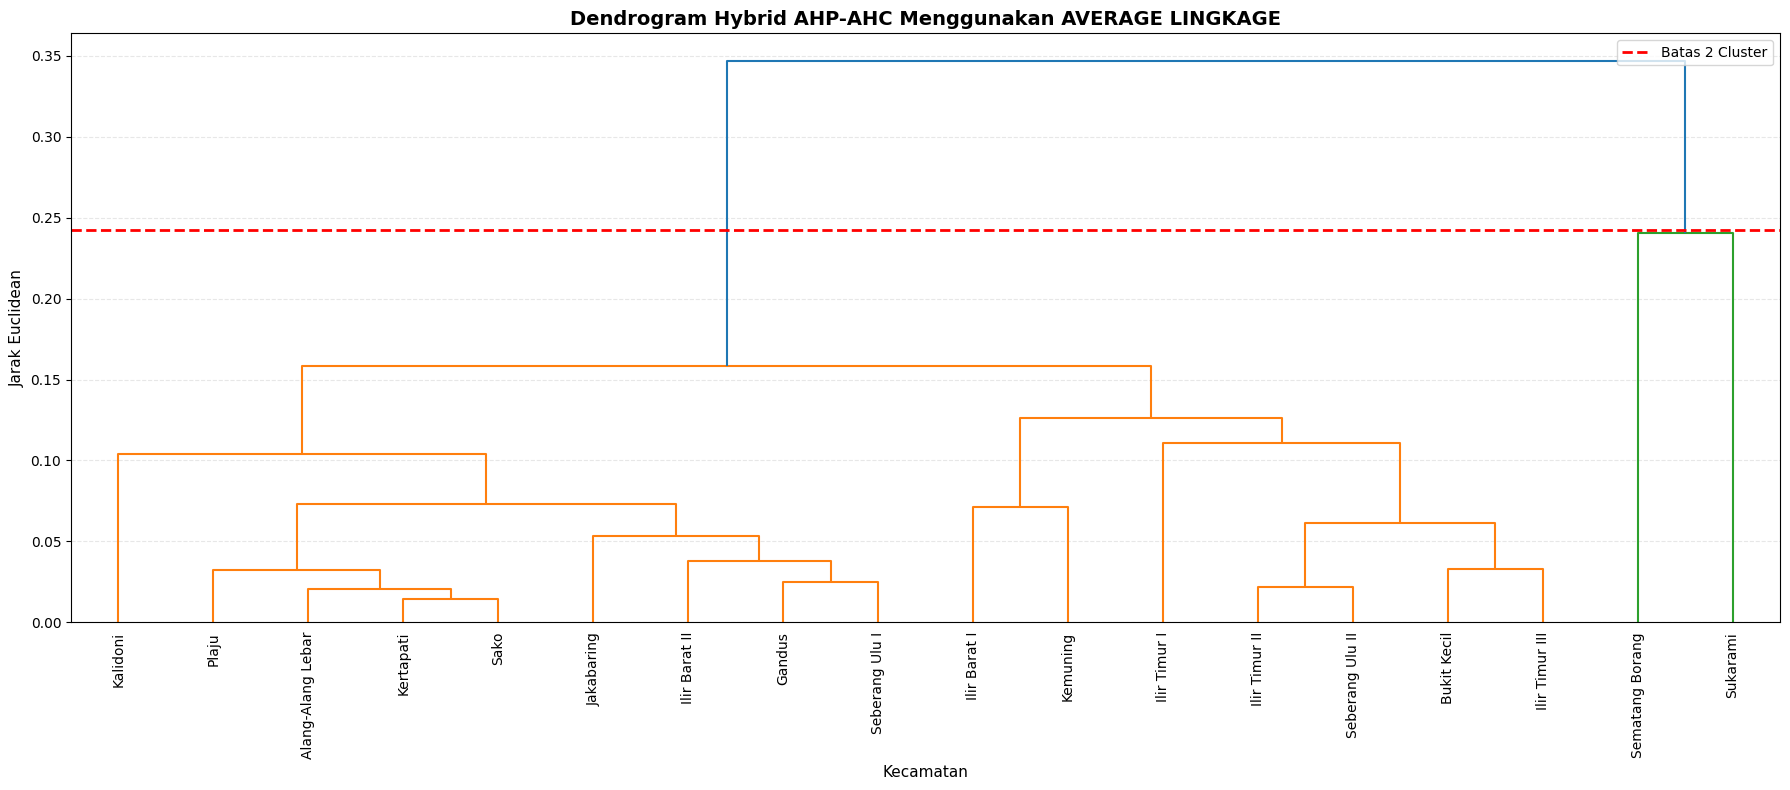


HASIL CLUSTER



,kecamatan,cluster_urut,kategori
0,Alang-Alang Lebar,1,Distribusi Guru Relatif Merata
15,Seberang Ulu II,1,Distribusi Guru Relatif Merata
14,Seberang Ulu I,1,Distribusi Guru Relatif Merata
13,Sako,1,Distribusi Guru Relatif Merata
12,Plaju,1,Distribusi Guru Relatif Merata
11,Kertapati,1,Distribusi Guru Relatif Merata
10,Kemuning,1,Distribusi Guru Relatif Merata
9,Kalidoni,1,Distribusi Guru Relatif Merata
8,Jakabaring,1,Distribusi Guru Relatif Merata
7,Ilir Timur III,1,Distribusi Guru Relatif Merata



DETAIL CLUSTER


CLUSTER 1
Kategori : Distribusi Guru Relatif Merata
Jumlah Kecamatan : 16
Rata-rata Rasio : 18.66


,kecamatan,penduduk,guru,siswa,rombel,rasio
5,Ilir Timur I,66.124,353,5648,234,16.00
7,Ilir Timur III,74.562,341,5869,232,17.21
1,Bukit Kecil,38.195,284,4941,196,17.40
3,Ilir Barat I,154.738,794,13976,549,17.60
10,Kemuning,82.167,632,11135,416,17.62
15,Seberang Ulu II,106.752,305,5512,217,18.07
6,Ilir Timur II,85.005,347,6279,265,18.10
12,Plaju,99.559,526,9983,391,18.98
11,Kertapati,99.576,476,9201,378,19.33
13,Sako,117.573,474,9165,353,19.34


--------------------------------------------------------------------------------

CLUSTER 2
Kategori : Distribusi Guru Belum Merata
Jumlah Kecamatan : 2
Rata-rata Rasio : 23.60


,kecamatan,penduduk,guru,siswa,rombel,rasio
17,Sukarami,212.241,834,19528,654,23.41
16,Sematang Borang,70.870,156,3712,123,23.79


--------------------------------------------------------------------------------


In [3]:
# =========================================================
# HYBRID AHP - AHC
# =========================================================

# ======================================
# 1. IMPORT LIBRARY
# ======================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster,
    cophenet
)

from scipy.spatial.distance import (
    pdist,
    squareform
)

# ======================================
# 2. DATA AWAL
# ======================================
df = pd.read_csv(
    r'D:\WEBSITE ME\simpegu1\dataset csv\per_kecamatan\data_awal_mentah_2024.csv',
    sep=';',
    header=0
)

# ======================================
# 3. UBAH NAMA KOLOM
# ======================================
df = df.rename(columns={

    'Kecamatan': 'kecamatan',
    'Penduduk': 'penduduk',
    'Guru': 'guru',
    'Siswa': 'siswa',
    'Rombel': 'rombel',
    'Rasio (S/G)': 'rasio'
})

print("DATA AWAL\n")

display(df)

# ======================================
# 4. FITUR
# ======================================
fitur = [

    'penduduk',
    'guru',
    'siswa',
    'rombel',
    'rasio'
]

# ======================================
# 5. NORMALISASI MIN-MAX
# ======================================
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(
    df[fitur]
)

# dataframe normalisasi
normalisasi_df = pd.DataFrame(

    X_scaled,

    columns=[
        f'{x}_indeks'
        for x in fitur
    ]
)

print("\nHASIL NORMALISASI INDEKS\n")

display(normalisasi_df)

# ======================================
# 6. MATRIKS AHP
# ======================================
A = np.array([

    [1,   1,   1,   1,   1/4],
    [1,   1,   1,   1,   1/4],
    [1,   1,   1,   1,   1/4],
    [1,   1,   1,   1,   1/4],
    [4,   4,   4,   4,   1]

], dtype=float)

# ======================================
# 7. NORMALISASI MATRIKS AHP
# ======================================
col_sum = A.sum(axis=0)

norm_A = A / col_sum

# ======================================
# 8. HITUNG BOBOT AHP
# ======================================
weights = norm_A.mean(axis=1)

# tabel bobot
bobot_df = pd.DataFrame({

    'Variabel': fitur,
    'Bobot': np.round(weights,4)
})

print("\nBOBOT AHP\n")

display(bobot_df)

# ======================================
# 9. UJI KONSISTENSI
# ======================================
n = A.shape[0]

lambda_max = (
    A @ weights / weights
).mean()

CI = (
    lambda_max - n
) / (
    n - 1
)

RI = 1.12

CR = CI / RI

print("\nHASIL UJI KONSISTENSI\n")

print("Lambda Max :", round(lambda_max,4))
print("CI          :", round(CI,4))
print("CR          :", round(CR,4))

if CR < 0.1:
    print("Keterangan : Konsisten")
else:
    print("Keterangan : Tidak Konsisten")

# ======================================
# 10. INDEKS BERBOBOT
# ======================================
weighted_df = pd.DataFrame(

    X_scaled * weights,

    columns=[
        f'{x}_weighted'
        for x in fitur
    ]
)

print("\nINDEKS BERBOBOT PER VARIABEL\n")

display(weighted_df)

# ======================================
# 11. DATA CLUSTERING
# ======================================
# memakai indeks berbobot

X_cluster = weighted_df.values

# ======================================
# 12. EUCLIDEAN DISTANCE
# ======================================
jarak_euclidean = pdist(

    X_cluster,
    metric='euclidean'
)

# matriks jarak
matriks_jarak = pd.DataFrame(

    squareform(jarak_euclidean),

    index=df['kecamatan'],
    columns=df['kecamatan']
)

print("\nMATRIKS EUCLIDEAN DISTANCE\n")

display(
    matriks_jarak.round(4)
)

# ======================================
# 13. CLUSTERING AHC
# ======================================

metode_ahc = 'average'

Z = linkage(

    X_cluster,

    method=metode_ahc,

    metric='euclidean'

)
# ======================================
# 14. SILHOUETTE SCORE
# ======================================
print("\nHASIL SILHOUETTE SCORE\n")

for k in range(2,10):

    cluster_test = fcluster(

        Z,
        k,
        criterion='maxclust'
    )

    score = silhouette_score(

        X_cluster,
        cluster_test,
        metric='euclidean'
    )

    print(
        f'Jumlah Cluster {k} = {score:.3f}'
    )

# ======================================
# 15. COPHENETIC CORRELATION
# ======================================
print("\nHASIL COPHENETIC CORRELATION\n")

jarak_asli = pdist(
    X_cluster,
    metric='euclidean'
)

metode_linkage = [

    'single',
    'complete',
    'average',
   
]

hasil_cophenetic = []

for metode in metode_linkage:

    Z_test = linkage(

        X_cluster,
        method=metode
    )

    coph_corr, coph_dist = cophenet(

        Z_test,
        jarak_asli
    )

    hasil_cophenetic.append([

        metode,
        round(coph_corr,4)
    ])

hasil_cophenetic = pd.DataFrame(

    hasil_cophenetic,

    columns=[

        'Metode Linkage',
        'Cophenetic Correlation'
    ]
)

hasil_cophenetic = hasil_cophenetic.sort_values(

    by='Cophenetic Correlation',
    ascending=False
)

print("\nHASIL EVALUASI COPHENETIC\n")

display(hasil_cophenetic)

# ======================================
# 16. JUMLAH CLUSTER
# ======================================
k = 2

# cluster akhir
cluster_final = fcluster(

    Z,
    k,
    criterion='maxclust'
)

# simpan cluster
df['cluster'] = cluster_final

# ======================================
# 17. RATA-RATA CLUSTER
# ======================================
cluster_mean = df.groupby(
    'cluster'
)['rasio'].mean()

print("\nRATA-RATA RASIO CLUSTER\n")

print(cluster_mean)

# ======================================
# 18. URUTKAN CLUSTER
# ======================================
sorted_cluster = (

    cluster_mean
    .sort_values()
    .index
    .tolist()
)

new_cluster = {

    old: new + 1

    for new, old
    in enumerate(sorted_cluster)
}

df['cluster_urut'] = (
    df['cluster']
    .map(new_cluster)
)

# ======================================
# 19. KATEGORI CLUSTER
# ======================================
if k == 2:

    kategori = {

        1: 'Distribusi Guru Relatif Merata',

        2: 'Distribusi Guru Belum Merata'
    }

elif k == 3:

    kategori = {

        1: 'Distribusi Guru Relatif Merata',

        2: 'Distribusi Guru Cukup Merata',

        3: 'Distribusi Guru Belum Merata'
    }

else:

    kategori = {
        i: f'Cluster {i}'
        for i in range(1, k+1)
    }

# simpan kategori
df['kategori'] = (
    df['cluster_urut']
    .map(kategori)
)

# ======================================
# 20. DENDROGRAM
# ======================================

plt.figure(figsize=(18,8))

# threshold pemotongan cluster
threshold = 0.7 * np.max(Z[:,2])

dendrogram(

    Z,

    labels=df['kecamatan'].tolist(),

    leaf_rotation=90,

    leaf_font_size=10,

    color_threshold=threshold

)

# garis pemotong cluster
plt.axhline(

    y=threshold,

    color='red',

    linestyle='--',

    linewidth=2,

    label=f'Batas {k} Cluster'

)

# judul otomatis sesuai metode
plt.title(

    f'Dendrogram Hybrid AHP-AHC Menggunakan {metode_ahc.upper()} LINGKAGE',

    fontsize=14,

    fontweight='bold'

)

plt.xlabel(

    'Kecamatan',

    fontsize=11

)

plt.ylabel(

    'Jarak Euclidean',

    fontsize=11

)

plt.legend()

plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.3

)

plt.tight_layout()

plt.show()

# ======================================
# 21. HASIL CLUSTER
# ======================================
hasil_cluster = df[[

    'kecamatan',
    'cluster_urut',
    'kategori'

]].sort_values('cluster_urut')

print("\nHASIL CLUSTER\n")

display(hasil_cluster)

# ======================================
# 22. DETAIL CLUSTER
# ======================================
print("\nDETAIL CLUSTER\n")

for c in sorted(df['cluster_urut'].unique()):

    data_cluster = df[
        df['cluster_urut'] == c
    ]

    print(f"\nCLUSTER {c}")
    print(
        f"Kategori : {data_cluster['kategori'].iloc[0]}"
    )

    print(
        f"Jumlah Kecamatan : {len(data_cluster)}"
    )

    print(
        f"Rata-rata Rasio : {data_cluster['rasio'].mean():.2f}"
    )

    display(
        data_cluster[[
            'kecamatan',
            'penduduk',
            'guru',
            'siswa',
            'rombel',
            'rasio'
        ]].sort_values('rasio')
    )

    print("-" * 80)